# **Modello LSTM per l'Analisi delle Recensioni di Amazon Fashion**
---
#Introduzione
Il seguente progetto è stato svolto in autonomia da **Valentina Jin**, matricola **0365400**. Il seguente codice implementa un modello LSTM per l'analisi delle recensioni di Amazon Fashion, con l'obiettivo di classificare le recensioni come positive o negative, quindi facendo la classificazione binaria. Il modello utilizza tecniche di preprocessamento, tokenizzazione e padding, seguite da una rete neurale ricorrente con strato LSTM bidirezionale per l'addestramento e la valutazione.


###Dataset
Il dataset usato **AmazonFashionBinary** contiene i dati pre-etichetati, in particolare, include due cartelle, una intitolata `0` contiene le recensioni negative in formato `.txt`, e l'altra intitolata `1` contiene le recensioni positive con lo stesso formato.


###Obiettivi
- Valutare l'accuratezza del modello, provando **almeno due diverse configurazioni** del modello.
- Verificare il funzionamento del modello su **messaggi scritti dall'utente**.

# Caricamento ed estrazione del file zip

In [60]:
import zipfile
import os

# Percorso al file zip
zip_path = '/content/AmazonFashionBinary.zip'
extract_path = '/content/AmazonFashionBinary_extracted'

# Estrarre il file zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Elenca i file e le cartelle all'interno di extract_path
os.listdir(extract_path)


['AmazonFashionBinary']

# Import necessari

In [61]:
import numpy as np
import pandas as pd
import os
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Configurazione del modello

Come si può vedere, viene considerato due configuzioni diverse del modello in `CONFIGS`, ottenute variando la lunghezza massima delle sequenze in input al modello. Vogliamo confrontare l'impatto sulle prestazioni del modello.
Viene inoltre definita una configurazione generale `BASE_CONFIG` contenente parametri chiave come il numero massimo di parole nel vocabolario, la dimensione degli embedding, la suddivisione del dataset e i parametri di addestramento.




In [62]:
# Configurazioni per confrontare diverse lunghezze massime delle sequenze
CONFIGS = [
    {"max_sequence_length": 50},
    {"max_sequence_length": 100}
]


# Configurazione generale
BASE_CONFIG = {
    "max_words": 5000,     # Numero massimo di parole nel vocabolario
    "embedding_dim": 50,   # Ogni parola sarà rappresentata da un vettore di 50 numeri
    "test_size": 0.10,
    "validation_size": 0.10,
    "epochs": 10,
    "batch_size": 16,    # Numero di campioni elaborati per aggiornare i pesi
    "early_stopping_patience": 3    # Interrompe l'addestramento se non migliora per 3 epoche consecutive
}

# Preprocessamento dei Dati


La funzione `preprocess_text` normalizza il testo convertendolo in minuscolo e rimuovendo la punteggiatura per rendere i dati più omogenei. Si osserva che non sono state rimosse le stopwords, perché provando già l'addestramento del modello rimuovendo le stopwords comporta abbassamento dell'accuratezza valutata sul test set finale, e mantenendo le stopwords il tempo di computazione rimane sostanzialmente uguale a quando le tolgo, per cui ho preferito di non rimuovere le stopwords per avere una maggior precisione.

In [63]:
# Funzione di pre-processamento
def preprocess_text(text):
    text = text.lower()  # Converti in minuscolo
    text = re.sub(r'[^\w\s]', '', text)  # Rimuove la punteggiatura
    return text

# Caricamento del dataset
Dopo l'estrazione del Dataset dallo ZIP, vediamo che le recensioni sono salvate in file di testo separati in due cartelle: una per le recensioni negative (0) e una per quelle positive (1). La funzione `load_data` legge i file che terminano con `.txt` e li converte in un DataFrame Pandas, in particolare, i dati vengono assegnati le etichette (0 per le recensioni negative, 1 per le recensioni positive).

In [64]:
# Caricamento dataset
def load_data(negative_path, positive_path):
    def load_files(folder, label):
        data = []
        for file in os.listdir(folder):
            file_path = os.path.join(folder, file)
            if os.path.isfile(file_path) and file.endswith(".txt"):
                with open(file_path, "r", encoding="utf-8") as f:
                    content = f.read()
                    data.append((preprocess_text(content), label))
        return data

    negative_reviews = load_files(negative_path, 0)
    positive_reviews = load_files(positive_path, 1)
    data = pd.DataFrame(negative_reviews + positive_reviews, columns=["review", "label"])
    return data

# Analisi del dataset
Il seguente codice analizza il dataset prima di fare addestramento, in particolare, viene contato il numero di recensioni per ciascun label e la lunghezza media delle recensioni.

In [65]:
def analyze_dataset(data):
    review_counts = data["label"].value_counts()
    print(f"Numero di recensioni negative: {review_counts[0]}")
    print(f"Numero di recensioni positive: {review_counts[1]}")

    # Conta il numero di parole per recensione
    data["word_count"] = data["review"].apply(lambda x: len(x.split()))

    # Media delle parole per recensione
    avg_words_per_review = data["word_count"].mean()
    print(f"Numero medio di parole per recensione: {avg_words_per_review:.2f}")

# Suddivisione del Dataset
Dopo il pre-processamento, i dati vengono divisi in training set (80%), validation set (10%) e test set (10%). Inoltre, ciascun set di dati ha una variabile `X` che indica "Feature/Input", che sono le recensioni testuali che usiamo come input del modello; e ha una variabile `y` che indica "Target/Label", che sono le etichette (0 = negativo, 1 = positivo) che indicano il sentiment della recensione.

In [66]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Suddivisione del dataset
def split_data(data):
    X_train, X_temp, y_train, y_temp = train_test_split(
        data["review"], data["label"], test_size=BASE_CONFIG["test_size"] + BASE_CONFIG["validation_size"], random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=BASE_CONFIG["test_size"] / (BASE_CONFIG["test_size"] + BASE_CONFIG["validation_size"]), random_state=42
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

# Tokenizzazione e Padding
La funzione `tokenize_and_pad` converte il testo in sequenze numeriche e le applica il padding alla fine della sequenza in caso la lunghezza di recensione è più corta di `max_sequence_length`, altrimenti la tronchiamo, ciò per garantire che tutte le sequenze abbiano la stessa lunghezza.

In [67]:
# Tokenizzazione e padding
def tokenize_and_pad(X_train, X_val, X_test, max_sequence_length):
    tokenizer = Tokenizer(num_words=BASE_CONFIG["max_words"], oov_token="<OOV>")
    tokenizer.fit_on_texts(X_train)

    X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_sequence_length, padding="post")
    X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=max_sequence_length, padding="post")
    X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_sequence_length, padding="post")

    return tokenizer, X_train_seq, X_val_seq, X_test_seq

# Creazione del Modello
La funzione `build_model` definisce e restituisce un modello di rete neurale basato su LSTM bidirezionale per la classificazione binaria delle recensioni. In sostanza, usa:
- **Embedding layer**: per trasformare ogni parola in un vettore numerico denso.
- **LSTM bidirectional**: per catturare le dipendenze tra le parole in entrambe le direzioni.
- **GlobalMaxPooling1D**: per ridurre l'output dell'LSTM estraendo il valore massimo per ogni feature, quindi aiuta a estrarre le caratteristiche più rilevanti della sequenza riducendo la dimensionalità.
- **Dense layer**: per apprendere pattern più complessi.
- **BatchNormalization**: per stabilizzare il training e prevenire overfitting.
- **Dropout**: per disattivare casualmente il 40% dei neuroni per prevenire overfitting.
- **Dense layer**: per effetturare la classificazione binaria usando la funzione Sigmoid che predice un valore tra 0 e 1. Se la probablità è > 0,5 allora la recensione è classificata Positiva, altrimenti è Negativa.

Dopodiché, il modello viene compilato con la loss function `binary_crossentropy` per misurare l'errore nella classificazione binaria, e con l'ottimizzatore `adam` per aggiornare i pesi per ridurre l'errore, monitorando come metrica di valutazione `accuracy`.

In [68]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.layers import GlobalMaxPooling1D, BatchNormalization
from tensorflow.keras.models import Sequential

# Creazione del modello
def build_model(max_sequence_length):
    model = Sequential([
        Embedding(BASE_CONFIG["max_words"], BASE_CONFIG["embedding_dim"], input_length=max_sequence_length),

        Bidirectional(LSTM(64, return_sequences=True)),

        GlobalMaxPooling1D(),

        Dense(64, activation='relu'),  # Layer denso per affinare le feature
        BatchNormalization(),
        Dropout(0.4),


        Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001))
    ])


    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

# Rappresenzione grafica
La funzione sottostante serve per rappresentare l'andamento di **Loss** e **Accuracy** sia del training set che del validation set durante l'addastramento.

In [69]:
def plot_training_history(history):
    # Estraggo i dati di loss e accuratezza
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    epochs = range(1, len(loss) + 1)

    # Grafico della Loss
    plt.figure(figsize=(8, 6))
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss durante il training')
    plt.legend()
    plt.grid()
    plt.show()

    # Grafico dell'Accuratezza
    plt.figure(figsize=(8, 6))
    plt.plot(epochs, accuracy, 'b', label='Training Accuracy')
    plt.plot(epochs, val_accuracy, 'r', label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuratezza durante il training')
    plt.legend()
    plt.grid()
    plt.show()

# Addestramento e Valutazione
La funzione `train_and_evaluate` addestra il modello e valuta le sue prestazioni con più configurazioni di lunghezza delle sequenze. Si osserva che viene applicato la tecnica di regolarizzazione **Early Stopping**, la quale interrompe anticipatamente l'addestramento del modello per evitare overfitting, in particolare, quando la `val_loss` non viene migliorata per numero di epoche fissate in `early_stopping_patience`.

Infine, viene valutata l'accuratezza rispetto al test set, e viene stampata la matrice di confusione per avere la visione più chiara sui risultati ottenuti. Dopodichè, viene testato il modello addestrato con gli input personalizzati.

In [70]:
from tensorflow.keras.callbacks import EarlyStopping

# Addestramento e valutazione
def train_and_evaluate(negative_path, positive_path, configs):
    data = load_data(negative_path, positive_path)

    # Esegue l'analisi del dataset prima di addestrare
    analyze_dataset(data)

    # Suddivide il dataset
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(data)

    results = {}
    # Iterazione su diverse configurazioni di lunghezza massima della sequenza
    for config in configs:
        max_sequence_length = config["max_sequence_length"]
        print(f"\nValutazione per max_sequence_length = {max_sequence_length}\n")

        # Converte le recensioni in sequenze numeriche
        tokenizer, X_train_seq, X_val_seq, X_test_seq = tokenize_and_pad(X_train, X_val, X_test, max_sequence_length)

        # Cotruisce il modello LSTM
        model = build_model(max_sequence_length)

        # Callback
        early_stopping = EarlyStopping(monitor='val_loss', patience=BASE_CONFIG["early_stopping_patience"], restore_best_weights=True, verbose=1)

        # Addestramento del modello
        history = model.fit(
            X_train_seq, y_train,    # Addestra il modello sui dati di training
            validation_data=(X_val_seq, y_val),   # Valida il modello sui dati di validazione
            epochs=BASE_CONFIG["epochs"],
            batch_size=BASE_CONFIG["batch_size"],
            shuffle=True,
            callbacks=[early_stopping]
        )

        # Stampare i grafici del andamento di Loss e Accuracy
        plot_training_history(history)

        # Valutazione sul test set
        y_pred = (model.predict(X_test_seq) > 0.5).astype("int32")    # Predice i risultati sul test set
        test_acc = accuracy_score(y_test, y_pred)     # Calcola l'accuratezza sul test set
        print(f"\nAccuratezza su test set: {test_acc:.4f}")

        # Matrice di confusione: mostra i falsi positivi, falsi negativi, veri positivi e veri negativi.
        cm = confusion_matrix(y_test, y_pred)

        # Visualizzazione con Seaborn
        plt.figure(figsize=(5, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
        plt.xlabel("Predetto")
        plt.ylabel("Reale")
        plt.title(f"Matrice di Confusione per max_length = {max_sequence_length}")
        plt.show()

        print("\nClassification Report:\n", classification_report(y_test, y_pred))

        results[max_sequence_length] = test_acc
        test_custom_reviews(model, tokenizer, max_sequence_length)

    return results


# Valutazione del modello su recensioni personalizzate
La funzione `test_custom_reviews` chiede all'utente di inserire una recensione, e ne predice la classe. Tale funzione serve per testare il modello addestrato su input personalizzati. Infatti, se la predizione ha valore > 0.5, allora la recensione viene classificata come Positiva, altrimenti Negativa.

In [71]:
# Funzione per testare il modello su input personalizzati
def test_custom_reviews(model, tokenizer, max_sequence_length):
    print("\nTesta il modello con messaggi personalizzati (digita 'exit' per uscire)")
    while True:
        user_input = input("Inserisci un messaggio: ")
        if user_input.lower() == 'exit':
            break
        processed_input = preprocess_text(user_input)
        input_sequence = pad_sequences(tokenizer.texts_to_sequences([processed_input]), maxlen=max_sequence_length)
        prediction = (model.predict(input_sequence) > 0.5).astype("int32")[0][0]
        print("Classificazione: Positiva" if prediction == 1 else "Classificazione: Negativa")

# Definizione dei percorsi del Dataset e Avvio dell'addestramento
Si osserva che i seguenti codici definiscono i percorsi del Dataset, sia delle recensioni negative che di quelle positive. Inoltre, viene chiamata la funzione `train_and_evaluate` per avviare l'addestramento del modello con le due configurazioni diverse. Alla fine viene stampato il confronto dell'accuratezza ottenuta dalle due configurazioni.

Numero di recensioni negative: 20000
Numero di recensioni positive: 20000
Numero medio di parole per recensione: 33.03

Valutazione per max_sequence_length = 50

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.8484 - loss: 0.3342 - val_accuracy: 0.9398 - val_loss: 0.1636
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9374 - loss: 0.1790 - val_accuracy: 0.9270 - val_loss: 0.2002
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9557 - loss: 0.1259 - val_accuracy: 0.9405 - val_loss: 0.1808
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9719 - loss: 0.0916 - val_accuracy: 0.9430 - val_loss: 0.1722
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


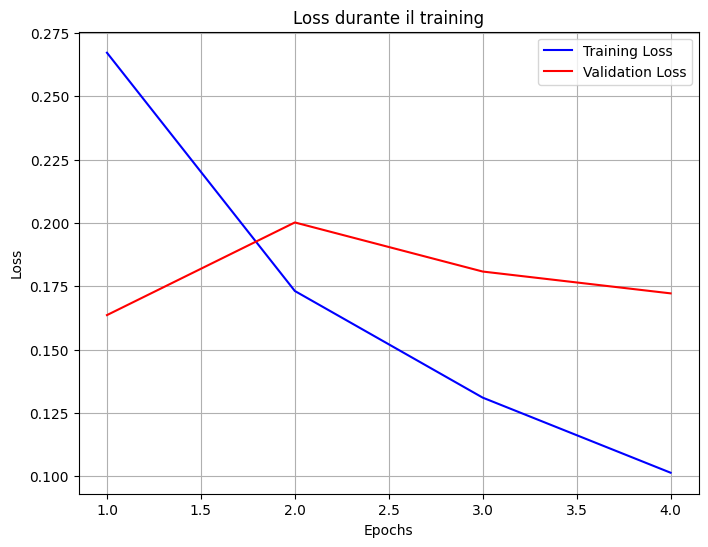

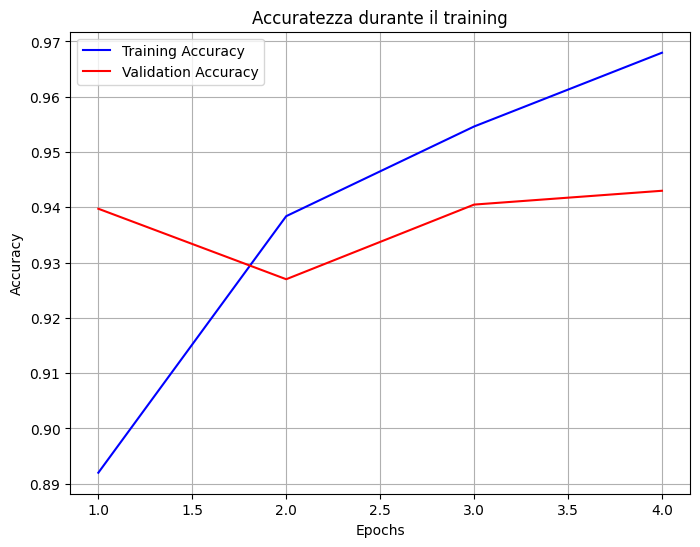

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Accuratezza su test set: 0.9355


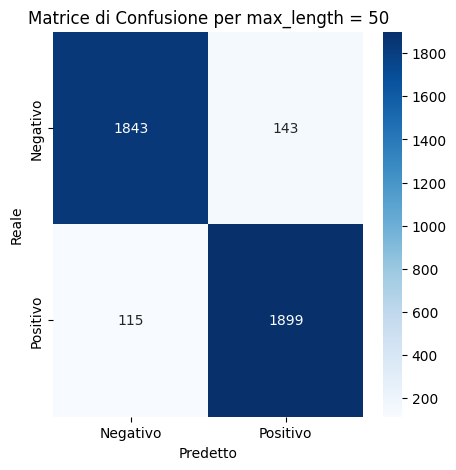


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93      1986
           1       0.93      0.94      0.94      2014

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000


Testa il modello con messaggi personalizzati (digita 'exit' per uscire)
Inserisci un messaggio: exit

Valutazione per max_sequence_length = 100

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.8594 - loss: 0.3233 - val_accuracy: 0.9340 - val_loss: 0.1684
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9437 - loss: 0.1615 - val_accuracy: 0.9463 - val_loss: 0.1450
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.9592 - loss: 0.1195 - val_accuracy: 0.9528 - val_loss: 0.1374
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.9730 - loss: 0.0864 - val_accuracy: 0.9320 - val_loss: 0.2017
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9774 - loss: 0.0716 - val_accuracy: 0.9498 - val_loss: 0.1558
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.9811 - loss: 0.0613 - val_accuracy: 0.9503 - val_loss: 0.1744
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


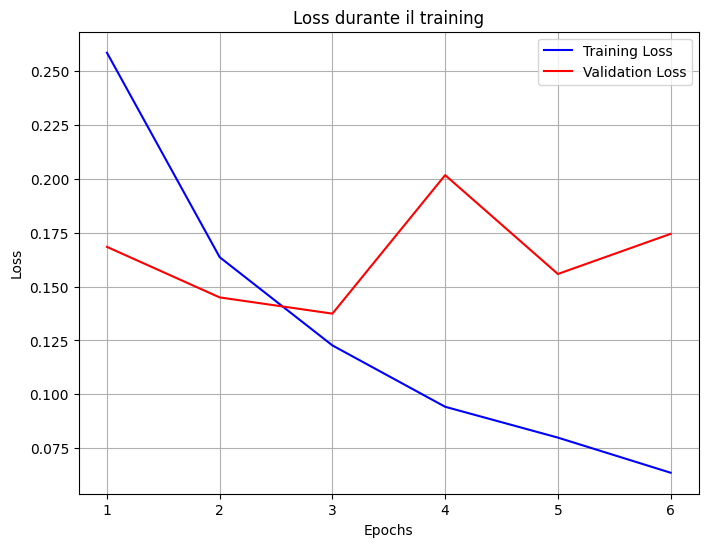

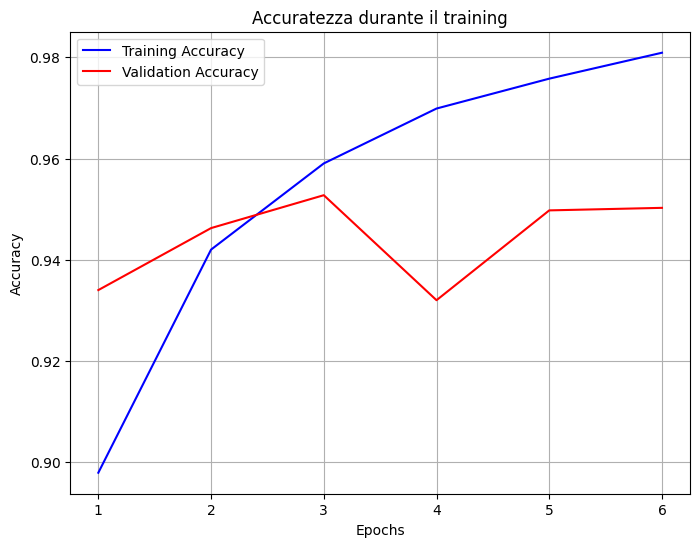

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Accuratezza su test set: 0.9503


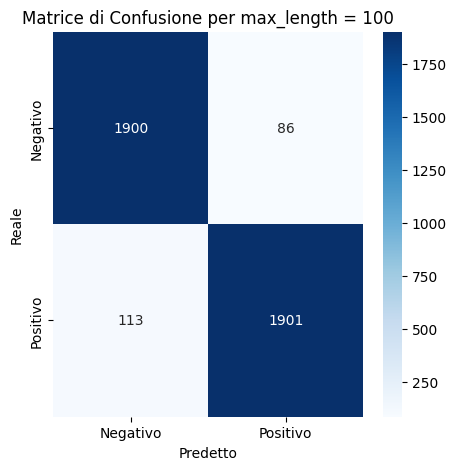


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95      1986
           1       0.96      0.94      0.95      2014

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000


Testa il modello con messaggi personalizzati (digita 'exit' per uscire)
Inserisci un messaggio: exit
Lunghezza max_sequence_length = 50, Accuratezza su test set = 0.9355
Lunghezza max_sequence_length = 100, Accuratezza su test set = 0.9503


In [72]:
# Definizione dei percorsi del dataset
dataset_path = "./AmazonFashionBinary_extracted/AmazonFashionBinary"
negative_path = os.path.join(dataset_path, "0")
positive_path = os.path.join(dataset_path, "1")

# Addestramento e confronto delle configurazioni
results = train_and_evaluate(negative_path, positive_path, CONFIGS)

# Stampa dei risultati
for length, acc in results.items():
    print(f"Lunghezza max_sequence_length = {length}, Accuratezza su test set = {acc:.4f}")


# Conclusione
Come si osserva, il modello è valutato tramite accuratezza su test set e vengono illutrati i risultati tramite la matrice di confusione. I risultati mostrano che l'aumento della lunghezza della sequenza migliora leggermente l'accuratezza, ma con un aumento del costo computazionale, che impatta maggiormente sul tempo di computazione.